# cDNA Translation

In [ ]:
import pandas as pd
import requests
from Bio.Seq import Seq

# 1. Target transcript IDs from isoform switch analysis
targets = {
    "ENSSSCT00000015650": {"gene": "MYOT", "shift": "Gain (0.00 -> 1.00)"},
    "ENSSSCT00000040313": {"gene": "MAPKAP1", "shift": "Gain (0.00 -> 1.00)"},
    "ENSSSCT00000057246": {"gene": "ARHGEF25", "shift": "Loss (1.00 -> 0.00)"},
    "ENSSSCT00000058845": {"gene": "PRPF18", "shift": "Gain (0.00 -> 1.00)"},
    "ENSSSCT00000067233": {"gene": "DDX19A", "shift": "Loss (1.00 -> 0.00)"},
    "ENSSSCT00000041995": {"gene": "KRT12", "shift": "Gain (0.00 -> 1.00)"},
}

prot_data = []

# 2. Fetch CDS sequence and perform standard translation
for tx_id, meta in targets.items():
    url = f"https://rest.ensembl.org/sequence/id/{tx_id}?type=cds"
    res = requests.get(url, headers={"Content-Type": "application/json"})

    if res.ok:
        cds_seq = res.json()["seq"]
        protein_seq = Seq(cds_seq).translate(to_stop=True)

        prot_data.append(
            {
                "Gene": meta["gene"],
                "Transcript_ID": tx_id,
                "Shift": meta["shift"],
                "CDS_len_bp": len(cds_seq),
                "Protein_len_aa": len(protein_seq),
                "Protein_Start": str(protein_seq[:20]),
            }
        )

# 3. View structural translation output
translation_df = pd.DataFrame(prot_data)
print(translation_df.to_string(index=False))

    Gene      Transcript_ID               Shift  CDS_len_bp  Protein_len_aa        Protein_Start
    MYOT ENSSSCT00000015650 Gain (0.00 -> 1.00)        1863             620 MSEIKKKTTRVSLNISSPVN
 MAPKAP1 ENSSSCT00000040313 Gain (0.00 -> 1.00)        1428             475 MAFLDNPTIILAHIRQSHVT
ARHGEF25 ENSSSCT00000057246 Loss (1.00 -> 0.00)        1743             580 MRGGQKGGRCACPHVIRKVL
  PRPF18 ENSSSCT00000058845 Gain (0.00 -> 1.00)         960             319 MDVLKSEILRKRQLVEDRNL
  DDX19A ENSSSCT00000067233 Loss (1.00 -> 0.00)        1437             478 MATDSWALAVDEQEAAVKSM
   KRT12 ENSSSCT00000041995 Gain (0.00 -> 1.00)        1560             519 MSLSVRTSGLSQRLSSQGGT


In [5]:
import pandas as pd
import requests

transcripts = [
    "ENSSSCT00000015650",
    "ENSSSCT00000040313",
    "ENSSSCT00000057246",
    "ENSSSCT00000058845",
    "ENSSSCT00000067233",
    "ENSSSCT00000041995",
]

domain_records = []

for tx_id in transcripts:
    # 1. Resolve Transcript ID (ENSSSCT) to Translation ID (ENSSSCP)
    lookup_url = f"https://rest.ensembl.org/lookup/id/{tx_id}?expand=1"
    lookup_res = requests.get(
        lookup_url, headers={"Content-Type": "application/json"}
    )

    if not lookup_res.ok:
        print(f"Failed to lookup transcript {tx_id}")
        continue

    tx_data = lookup_res.json()
    translation_id = tx_data.get("Translation", {}).get("id")

    if not translation_id:
        print(f"No translation ID found for transcript {tx_id}")
        continue

    # 2. Fetch domain features using the retrieved Translation ID
    domain_url = f"https://rest.ensembl.org/overlap/translation/{translation_id}?feature=protein_feature"
    domain_res = requests.get(
        domain_url, headers={"Content-Type": "application/json"}
    )

    if domain_res.ok:
        features = domain_res.json()
        for ft in features:
            domain_records.append(
                {
                    "Transcript_ID": tx_id,
                    "Translation_ID": translation_id,
                    "Database": ft.get("dbname"),
                    "Domain_ID": ft.get("id"),
                    "Description": ft.get("description", "N/A"),
                    "AA_Start": ft.get("start"),
                    "AA_End": ft.get("end"),
                }
            )

domain_df = pd.DataFrame(domain_records)
domain_df.to_csv(
    "../data/processed/protein_domain_annotations.csv", index=False
)
print(f"Retrieved {len(domain_df)} protein domain annotations successfully.\n")
print(domain_df.head(10).to_string(index=False))

Retrieved 91 protein domain annotations successfully.

     Transcript_ID     Translation_ID Database   Domain_ID                Description  AA_Start  AA_End
ENSSSCT00000015650 ENSSSCP00000015237     None     cd05892             IgI_Myotilin_C       471     562
ENSSSCT00000015650 ENSSSCP00000015237     None     PS50835 Immunoglobulin-like domain       471     561
ENSSSCT00000015650 ENSSSCP00000015237     None     PS50835 Immunoglobulin-like domain        60     158
ENSSSCT00000015650 ENSSSCP00000015237     None     PS50835 Immunoglobulin-like domain       372     457
ENSSSCT00000015650 ENSSSCP00000015237     None   PTHR10075            BASIGIN RELATED        56     258
ENSSSCT00000015650 ENSSSCP00000015237     None mobidb-lite        disorder_prediction       324     363
ENSSSCT00000015650 ENSSSCP00000015237     None mobidb-lite        disorder_prediction       242     260
ENSSSCT00000015650 ENSSSCP00000015237     None mobidb-lite        disorder_prediction       242     273
ENSSSCT00

# Per-Replicate Domain Abundance Workflow

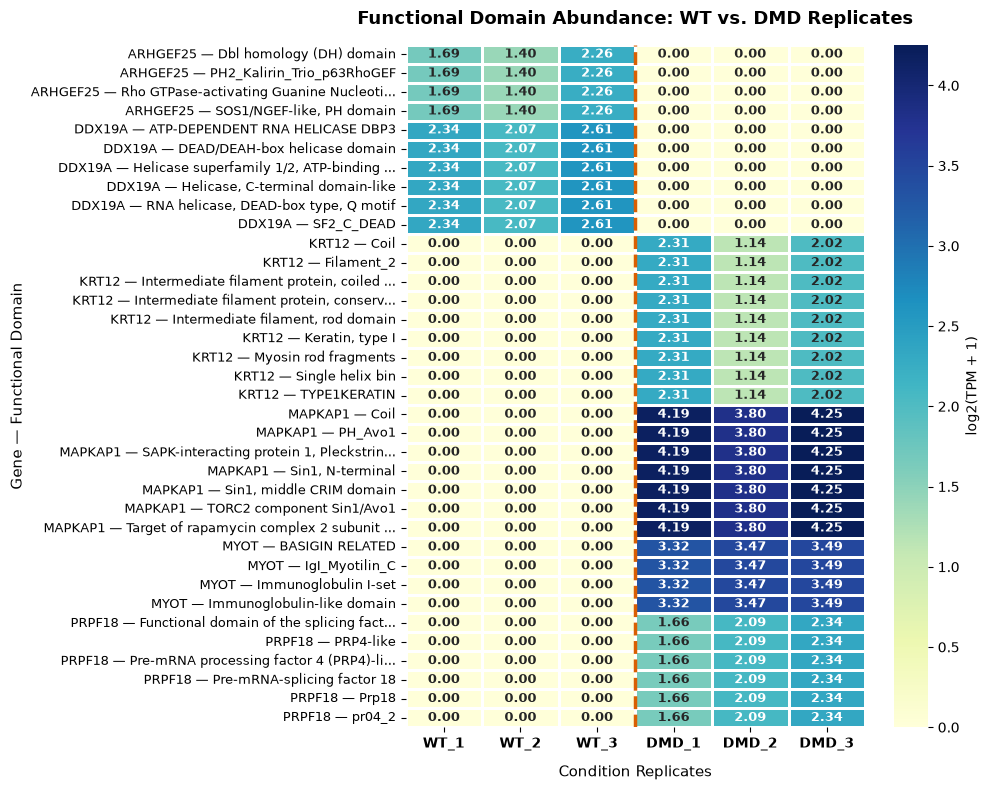

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# 1. Load data
splicing_df = pd.read_csv("../data/processed/splicing_matrix.csv")
domain_df = pd.read_csv("../data/processed/protein_domain_annotations.csv")

# Define SRA Replicates
wt_runs = ["SRR32086846", "SRR32086848", "SRR32086850"]
dmd_runs = ["SRR32086830", "SRR32086832", "SRR32086836"]
sample_cols = wt_runs + dmd_runs

# 2. Filter out raw UniParc mapping strings & disorder predictions
clean_domains = domain_df.dropna(subset=["Description"]).copy()

# Remove string artifacts and redundant disorder predictions
noise_mask = ~clean_domains["Description"].str.contains(
    "UniParc|alpha_version|disorder_prediction", case=False, na=False
)
clean_domains = clean_domains[noise_mask]

# Truncate any overly long domain names for neat rendering
clean_domains["Clean_Desc"] = clean_domains["Description"].apply(
    lambda x: x[:38] + "..." if len(x) > 38 else x
)

# Deduplicate so each transcript has 1 row per unique functional domain
clean_domains = clean_domains[
    ["Transcript_ID", "Clean_Desc"]
].drop_duplicates()

# 3. Merge with sample TPM expression matrix
merged_df = clean_domains.merge(
    splicing_df[["Transcript_ID", "Gene_Name"] + sample_cols],
    on="Transcript_ID",
    how="inner",
)

# Create clean label: "Gene — Short Domain Description"
merged_df["Domain_Feature"] = (
    merged_df["Gene_Name"] + " — " + merged_df["Clean_Desc"]
)

# Aggregate expression to Domain Feature level
domain_tpm = merged_df.groupby("Domain_Feature")[sample_cols].mean()
domain_tpm = domain_tpm.sort_index()

# Log2 transformation: log2(TPM + 1)
log2_domain_tpm = np.log2(domain_tpm + 1)

# 4. Generate polished heatmap
fig, ax = plt.subplots(figsize=(10, 8))

sns.heatmap(
    log2_domain_tpm,
    annot=True,
    fmt=".2f",
    cmap="YlGnBu",
    cbar_kws={"label": "log2(TPM + 1)"},
    linewidths=0.8,
    annot_kws={"size": 9, "weight": "bold"},
    ax=ax,
)

# Visual formatting & split line
ax.axvline(3, color="#d95f02", linestyle="--", linewidth=2.5)

ax.set_title(
    "Functional Domain Abundance: WT vs. DMD Replicates",
    fontsize=13,
    fontweight="bold",
    pad=15,
)
ax.set_xlabel("Condition Replicates", fontsize=11, labelpad=10)
ax.set_ylabel("Gene — Functional Domain", fontsize=11)

# Clean tick labels
sample_labels = [f"WT_{i+1}" for i in range(3)] + [
    f"DMD_{i+1}" for i in range(3)
]
ax.set_xticklabels(
    sample_labels, rotation=0, fontsize=10, fontweight="bold"
)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=9)

plt.tight_layout()
plt.savefig(
    "../data/processed/clean_domain_heatmap.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()